# SSP-SLAM Full Pipeline Demo
**Normal camera → Event camera → Feature extraction → Spiking SLAM → Cognitive Map**

Steps:
1. Load real 3D trajectory data and RGB frame(s)
2. Simulate an event (DVS) camera — if only one RGB frame is available, synthetic
   camera motion is generated automatically so the event demo still runs
3. Compare normal vs event-camera representations
4. Extract visual features
5. Run SSP-SLAM (or load a saved result)
6. Visualise the learned cognitive map as spatial heatmaps

**Requirements:** `pip install nengo nengo_spa numpy scipy matplotlib scikit-image`

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, sys, json, glob, re, time

NOTEBOOK_DIR = os.path.abspath(".")
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

DATA_DIR = os.path.join(PROJECT_ROOT, "data", "3d")
print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Files: {sorted(os.listdir(DATA_DIR))}")

Project root: C:\Users\30068379\OneDrive - Western Sydney University\Code\Semantic-Spiking-Neural-SLAM-2023
Data dir:     C:\Users\30068379\OneDrive - Western Sydney University\Code\Semantic-Spiking-Neural-SLAM-2023\data\3d
Files: ['feature_vectors.npy', 'landmark_positions.npy', 'metadata.json', 'path.npy', 'pipeline_summary.png', 'rgb_frames_subset.npy', 'slam_features_sspdim_97_featdim_128_pinneurons_300_T_30_seed_0.npz', 'slam_features_sspdim_97_featdim_512_pinneurons_300_T_0_seed_0.npz', 'slam_features_sspdim_97_featdim_9576_pinneurons_300_T_0_seed_0.npz', 'vec_to_landmarks.npy', 'velocities.npy']


---
## Section 1 — Load Trajectory Data

In [18]:
path               = np.load(os.path.join(DATA_DIR, "path.npy"))               # (T, 2)
velocities         = np.load(os.path.join(DATA_DIR, "velocities.npy"))         # (T, 2)
vec_to_landmarks   = np.load(os.path.join(DATA_DIR, "vec_to_landmarks.npy"))   # (T, N, 2)
landmark_positions = np.load(os.path.join(DATA_DIR, "landmark_positions.npy")) # (N, 2)
feature_vectors    = np.load(os.path.join(DATA_DIR, "feature_vectors.npy"))    # (T, N, feat_dim)
rgb_frames_raw     = np.load(os.path.join(DATA_DIR, "rgb_frames_subset.npy"))  # (K, H, W, 3)

with open(os.path.join(DATA_DIR, "metadata.json")) as f:
    meta = json.load(f)

COLORS          = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange', 'tab:purple', 'tab:cyan']
landmark_labels = meta["landmark_labels"]
n_steps, n_objects, feat_dim = feature_vectors.shape

print(f"Steps:           {n_steps}")
print(f"Objects:         {n_objects}  {landmark_labels}")
print(f"Feature dim:     {feat_dim}  ({meta['feat_method'].upper()})")
print(f"RGB frames raw:  {rgb_frames_raw.shape}")
print(f"Path range x:    [{path[:,0].min():.2f}, {path[:,0].max():.2f}]")
print(f"Path range y:    [{path[:,1].min():.2f}, {path[:,1].max():.2f}]")

Steps:           50
Objects:         4  ['red_box', 'blue_box', 'green_ball', 'yellow_ball']
Feature dim:     9576  (HOG)
RGB frames raw:  (1, 120, 160, 3)
Path range x:    [-0.75, -0.10]
Path range y:    [0.15, 0.51]


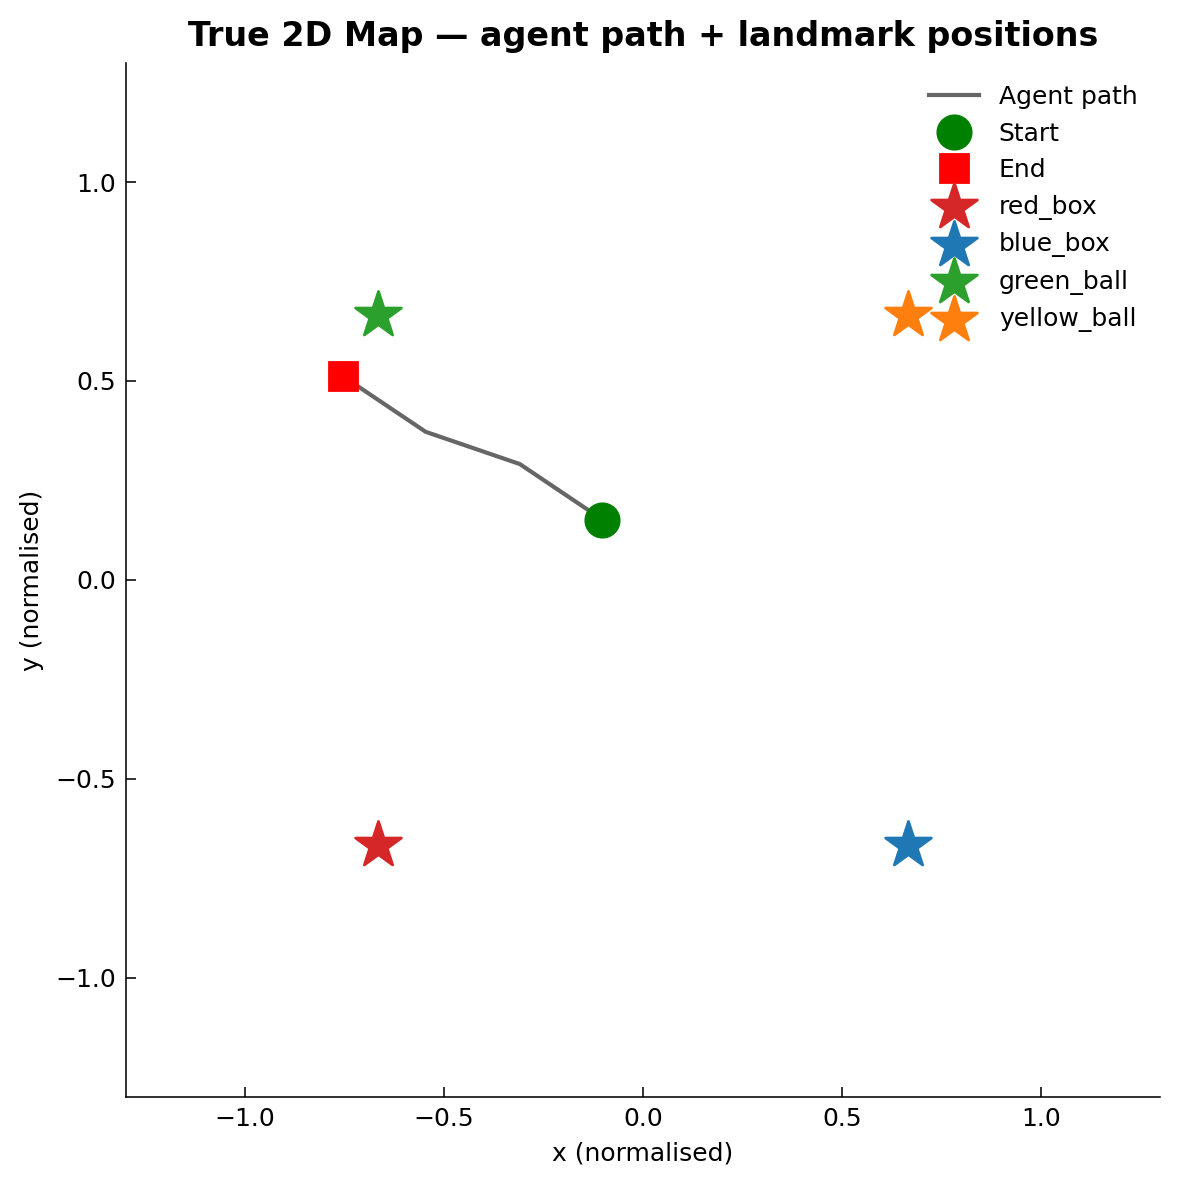

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(path[:, 0], path[:, 1], 'k-', lw=1.5, alpha=0.6, label='Agent path')
ax.plot(path[0, 0], path[0, 1], 'go', ms=12, zorder=6, label='Start')
ax.plot(path[-1, 0], path[-1, 1], 'rs', ms=10, zorder=6, label='End')
for i, (pos, lbl) in enumerate(zip(landmark_positions, landmark_labels)):
    ax.scatter(*pos, s=300, marker='*', color=COLORS[i], zorder=5, label=lbl)
ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
ax.set_aspect('equal')
ax.legend(fontsize=9, loc='upper right')
ax.set_title("True 2D Map — agent path + landmark positions", fontsize=12)
ax.set_xlabel('x (normalised)'); ax.set_ylabel('y (normalised)')
plt.tight_layout(); plt.show()

---
## Section 2 — Normal Camera: RGB Frame(s)

Only 1 RGB frame(s) stored — generating 40 synthetic motion frames.
Synthetic frames: (40, 120, 160, 3)


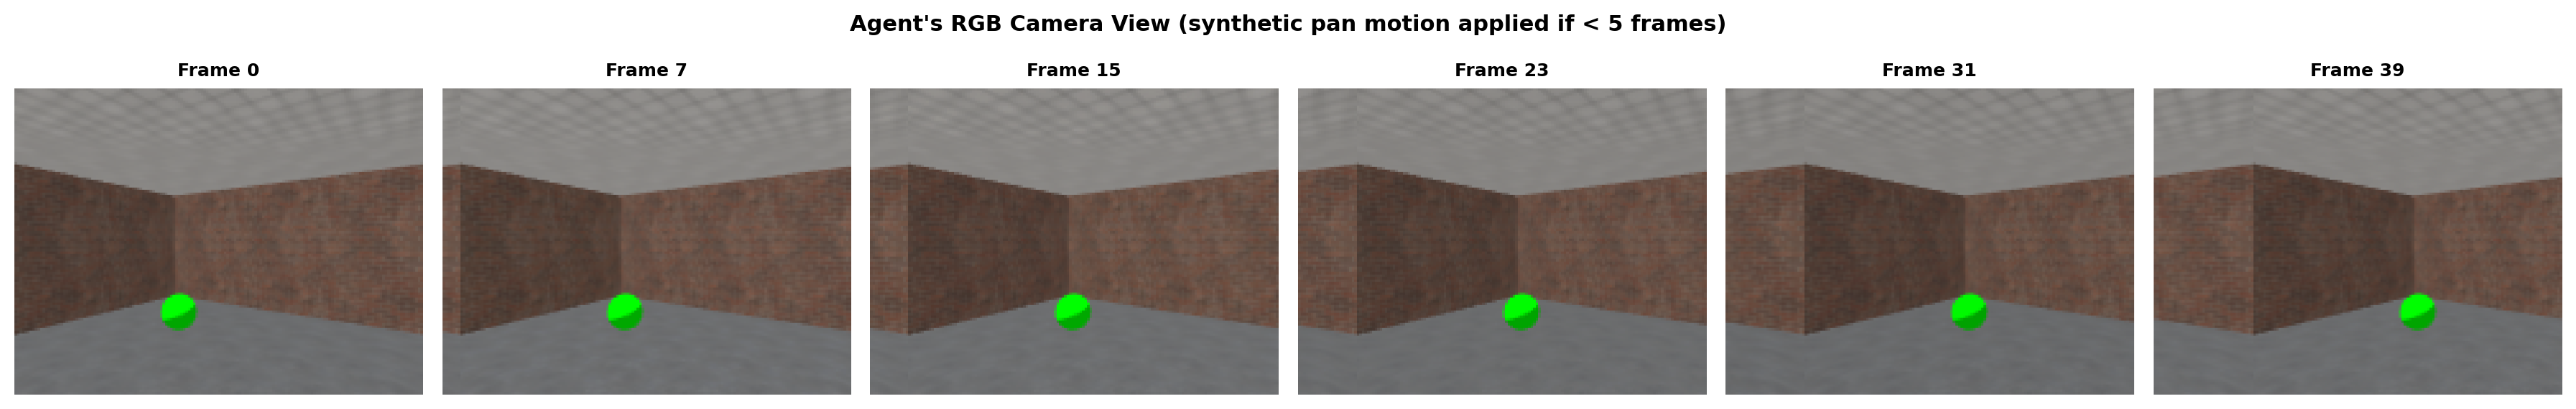

In [20]:
# If we only stored 1 frame (50-step dataset with [::100] stride),
# synthesise camera motion by translating the frame — this gives the
# event simulator something real to work with.
N_MOTION = 40   # how many synthetic motion frames to generate

if len(rgb_frames_raw) < 5:
    print(f"Only {len(rgb_frames_raw)} RGB frame(s) stored — generating {N_MOTION} synthetic motion frames.")
    base = rgb_frames_raw[0].astype(np.float32)
    motion_frames = []
    for i in range(N_MOTION):
        # Horizontal pan of 1 pixel per frame (wrapping)
        shifted = np.roll(base, shift=i, axis=1)
        # Add a small brightness ramp to create more events
        brightness_mod = 1.0 + 0.02 * np.sin(2 * np.pi * i / N_MOTION)
        shifted = (shifted * brightness_mod).clip(0, 255).astype(np.uint8)
        motion_frames.append(shifted)
    rgb_frames = np.stack(motion_frames)  # (N_MOTION, H, W, 3)
    print(f"Synthetic frames: {rgb_frames.shape}")
else:
    rgb_frames = rgb_frames_raw
    print(f"Using {len(rgb_frames)} stored RGB frames")

n_show = min(len(rgb_frames), 6)
indices = np.linspace(0, len(rgb_frames) - 1, n_show, dtype=int)
fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3))
if n_show == 1: axes = [axes]
for ax, idx in zip(axes, indices):
    ax.imshow(rgb_frames[idx])
    ax.axis('off')
    ax.set_title(f"Frame {idx}", fontsize=9)
plt.suptitle("Agent's RGB Camera View (synthetic pan motion applied if < 5 frames)", fontsize=11)
plt.tight_layout(); plt.show()

---
## Section 3 — Event Camera Simulation
A DVS camera fires *events* whenever log-brightness changes beyond a threshold.
Instead of full frames at fixed intervals it outputs sparse `(t, x, y, polarity)` tuples.

In [21]:
from sspslam.perception.event_simulator import ContrastThresholdEventSimulator

ev_sim = ContrastThresholdEventSimulator(
    C_pos=0.05, C_neg=0.05,   # low threshold → sensitive to small changes
    refractory_period=0.001,
    dt=1/30,
    noise_rate=0.01,
    seed=0,
)

event_frames, event_times, raw_events = ev_sim.simulate(rgb_frames, dt_window=0.1)

print(f"Input RGB frames:   {rgb_frames.shape}")
print(f"Raw events fired:   {len(raw_events):,}")
print(f"Event frames out:   {event_frames.shape}")
if len(raw_events) > 0:
    print(f"  polarity +1:  {(raw_events[:,3] > 0).sum():,}  (brighter)")
    print(f"  polarity -1:  {(raw_events[:,3] < 0).sum():,}  (darker)")

Input RGB frames:   (40, 120, 160, 3)
Raw events fired:   117,140
Event frames out:   (13, 120, 160)
  polarity +1:  55,974  (brighter)
  polarity -1:  61,166  (darker)


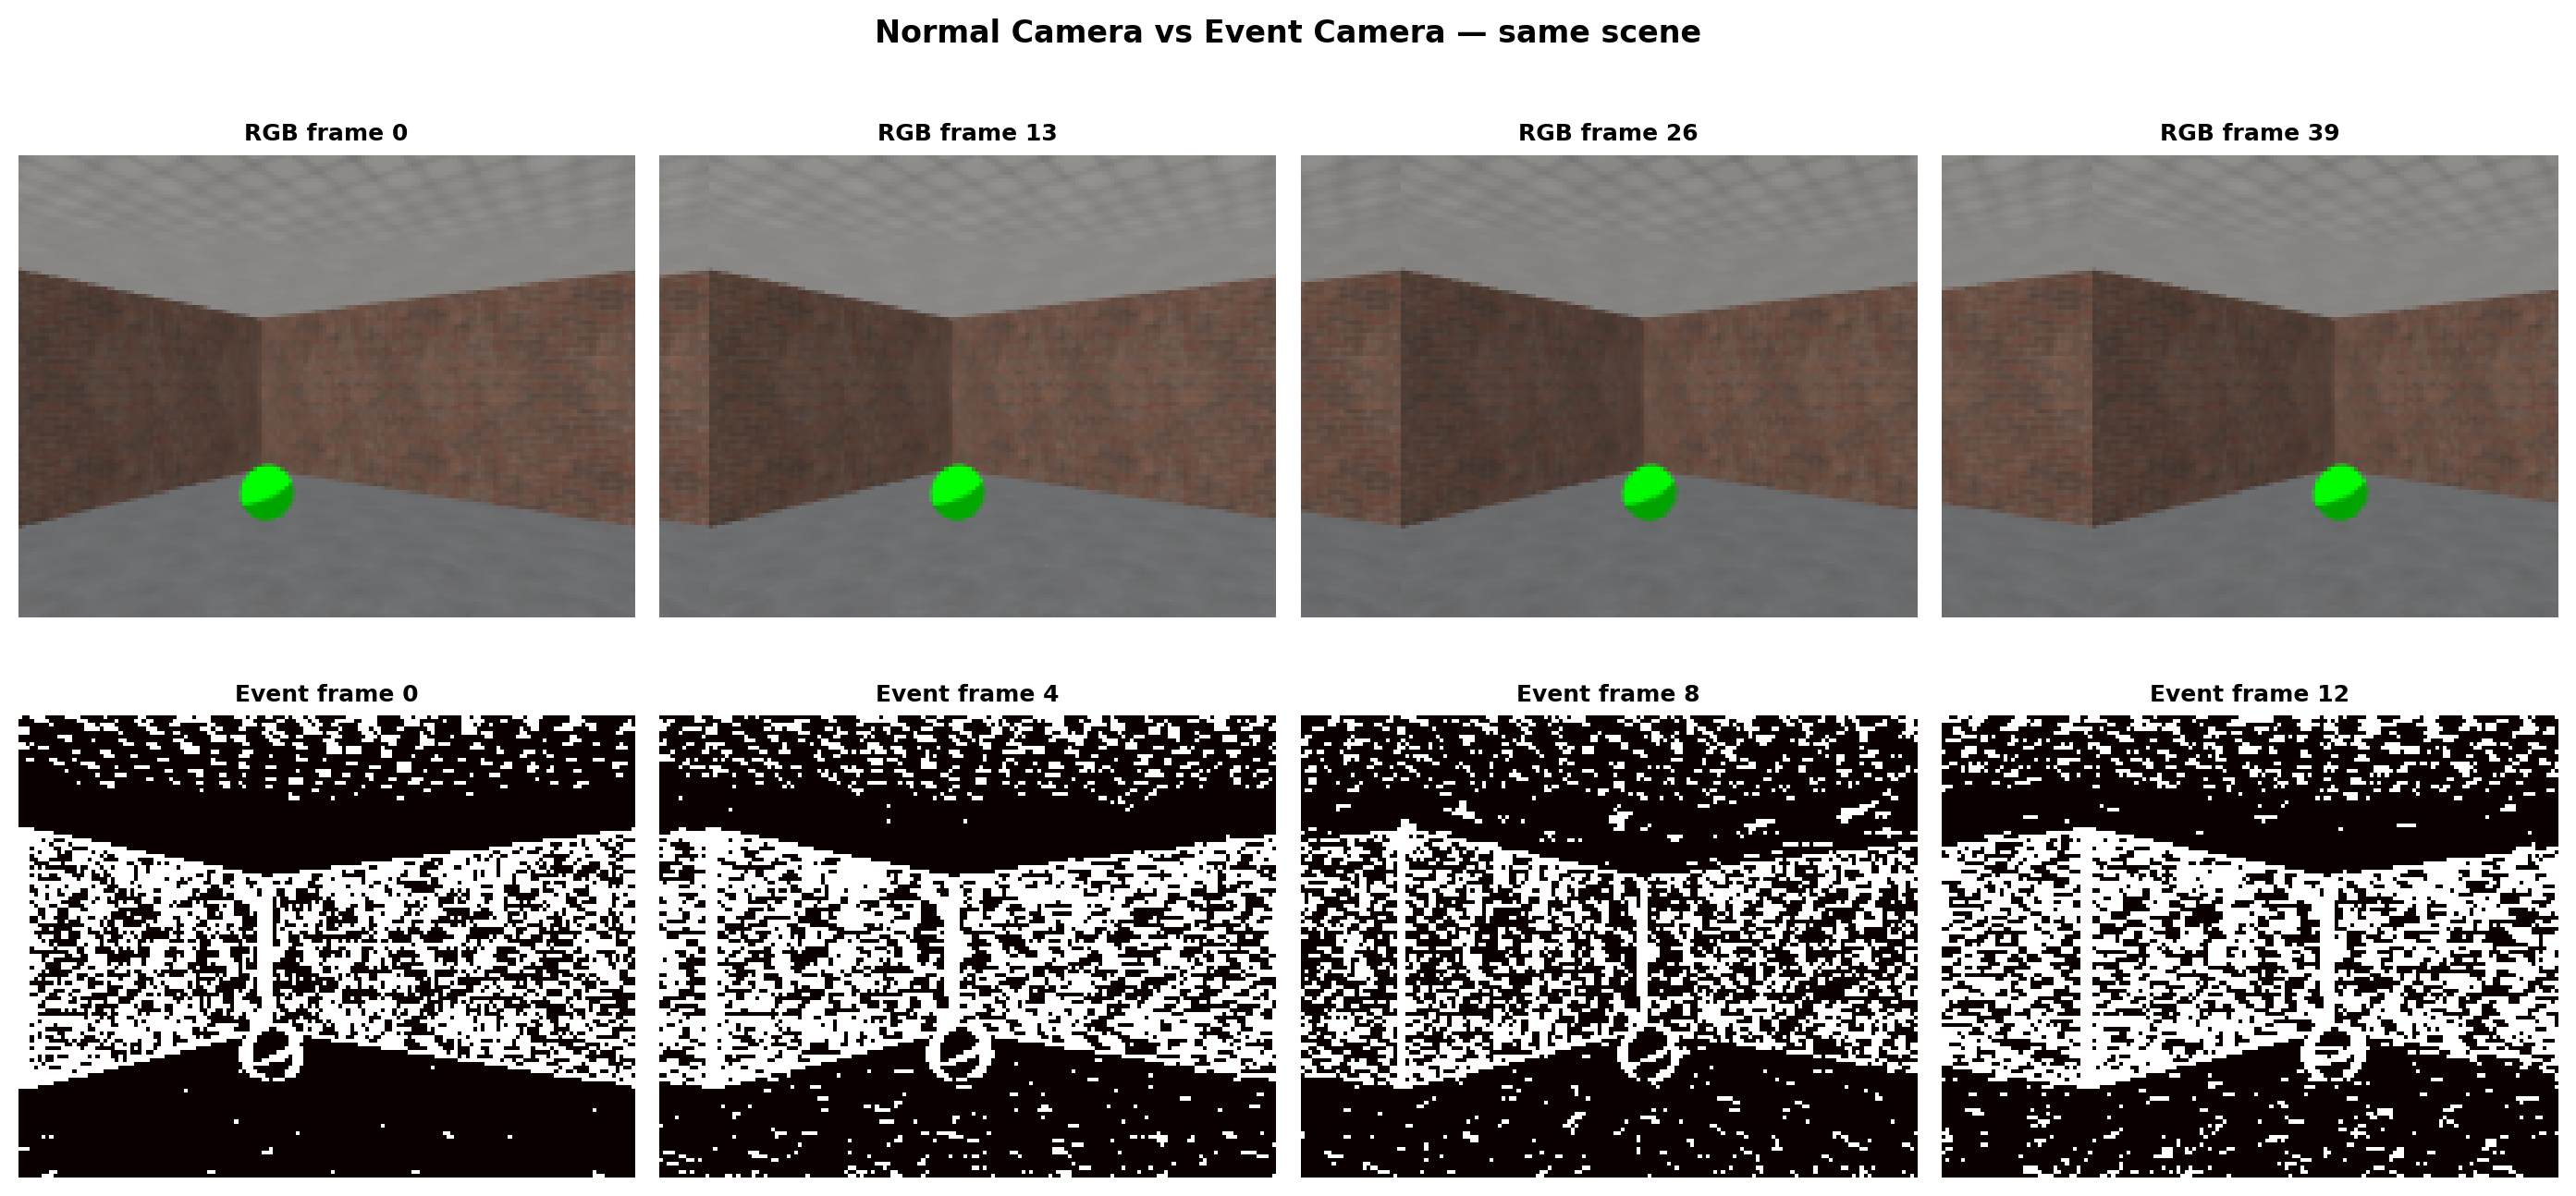

In [22]:
n_show = min(len(rgb_frames), len(event_frames), 4)
rgb_indices = np.linspace(0, len(rgb_frames) - 1, n_show, dtype=int)
ev_indices  = np.linspace(0, len(event_frames) - 1, n_show, dtype=int)

fig, axes = plt.subplots(2, n_show, figsize=(3.5 * n_show, 7))
if n_show == 1:
    axes = axes.reshape(2, 1)
for col in range(n_show):
    axes[0, col].imshow(rgb_frames[rgb_indices[col]])
    axes[0, col].axis('off')
    axes[0, col].set_title(f"RGB frame {rgb_indices[col]}", fontsize=9)

    ev_max = event_frames[ev_indices[col]].max()
    axes[1, col].imshow(event_frames[ev_indices[col]], cmap='hot',
                        vmin=0, vmax=max(ev_max, 1))
    axes[1, col].axis('off')
    axes[1, col].set_title(f"Event frame {ev_indices[col]}", fontsize=9)

axes[0, 0].set_ylabel("Normal\ncamera", fontsize=10, rotation=0, labelpad=60, va='center')
axes[1, 0].set_ylabel("Event\ncamera", fontsize=10, rotation=0, labelpad=60, va='center')
plt.suptitle("Normal Camera vs Event Camera — same scene", fontsize=12)
plt.tight_layout(); plt.show()

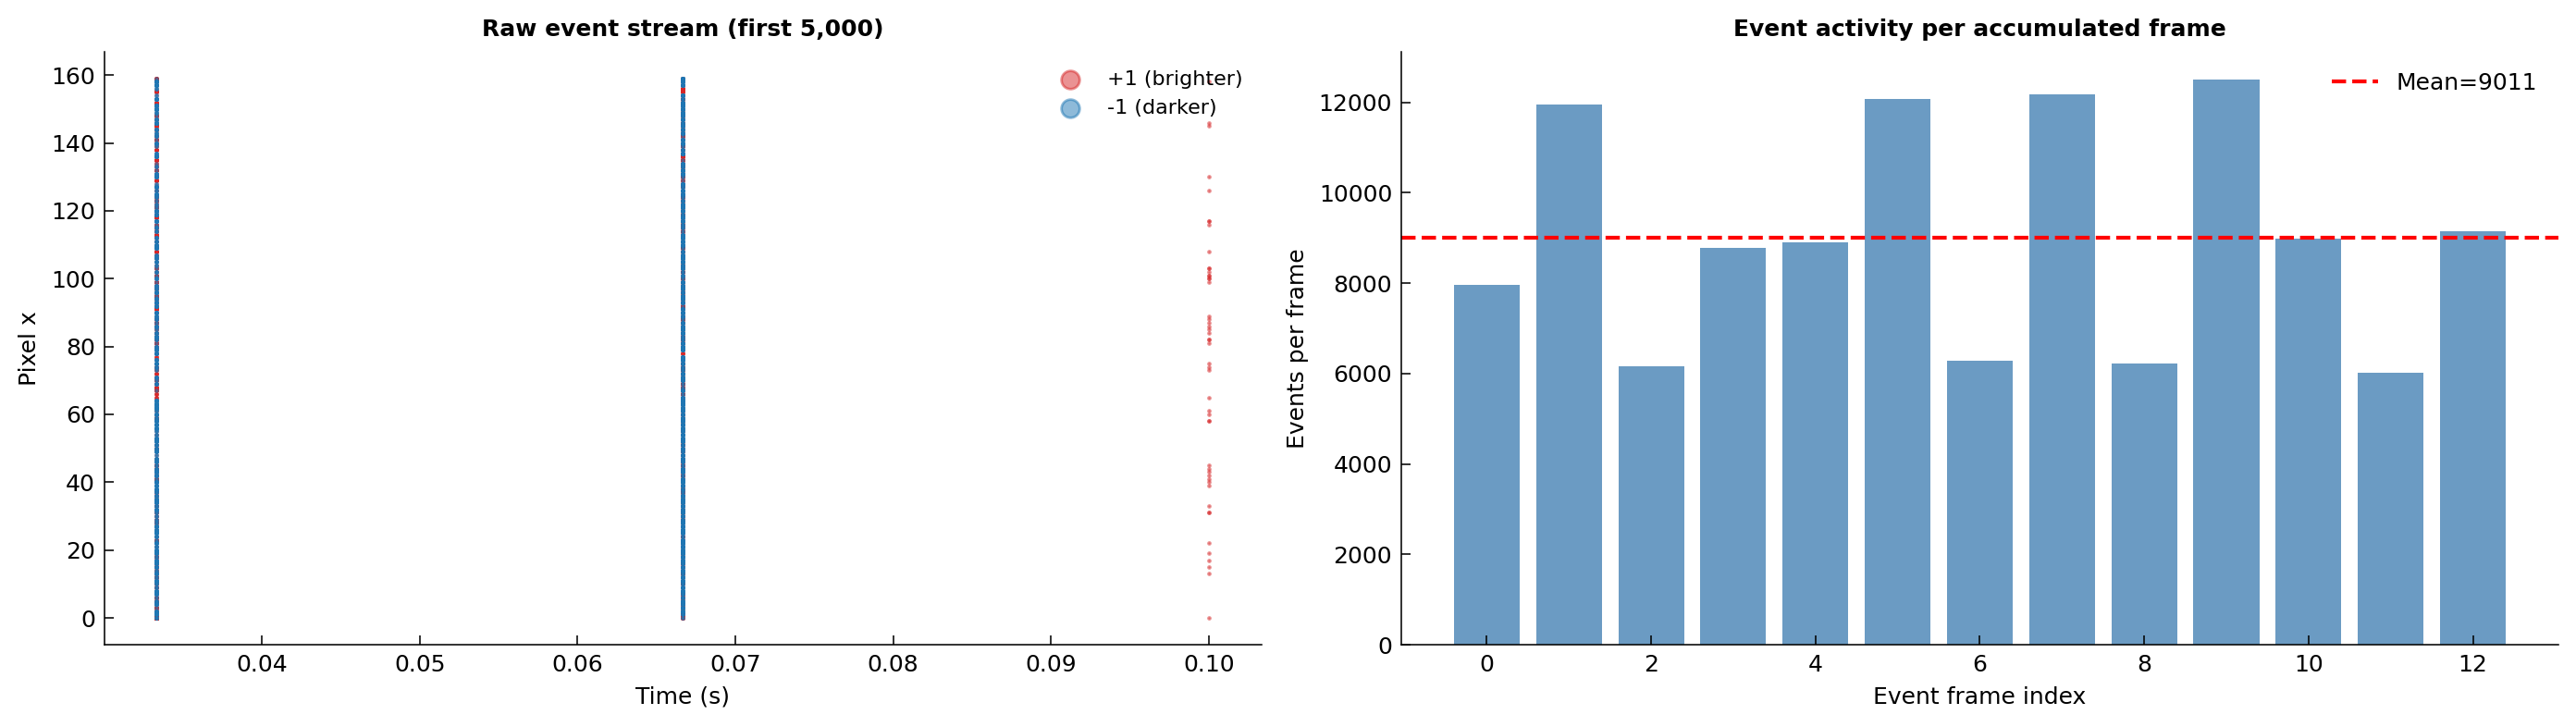

In [23]:
if len(raw_events) == 0:
    print("No events to plot — try lowering C_pos/C_neg thresholds in the cell above.")
else:
    N_show = min(5000, len(raw_events))
    ev = raw_events[:N_show]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    pos_mask = ev[:, 3] > 0
    axes[0].scatter(ev[pos_mask, 0], ev[pos_mask, 1],
                    s=0.5, c='tab:red', alpha=0.5, label='+1 (brighter)')
    axes[0].scatter(ev[~pos_mask, 0], ev[~pos_mask, 1],
                    s=0.5, c='tab:blue', alpha=0.5, label='-1 (darker)')
    axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Pixel x')
    axes[0].set_title(f'Raw event stream (first {N_show:,})')
    axes[0].legend(fontsize=8, markerscale=10)

    frame_ids = np.searchsorted(event_times, raw_events[:, 0])
    counts = np.bincount(frame_ids.clip(0, len(event_times)-1), minlength=len(event_times))
    axes[1].bar(range(len(counts)), counts, color='steelblue', alpha=0.8)
    axes[1].axhline(counts.mean(), color='red', ls='--', lw=1.5,
                    label=f'Mean={counts.mean():.0f}')
    axes[1].set_xlabel('Event frame index'); axes[1].set_ylabel('Events per frame')
    axes[1].set_title('Event activity per accumulated frame')
    axes[1].legend(fontsize=9)

    plt.tight_layout(); plt.show()

---
## Section 4 — Feature Extraction
Extract HOG descriptors from both RGB and event frames, then inspect the pre-collected
`feature_vectors.npy` (used for SLAM) to confirm objects are distinguishable.

In [24]:
from sspslam.perception.image_feature_encoder import extract_hog

rgb_hog = np.array([extract_hog(f) for f in rgb_frames])
ev_hog  = np.array([extract_hog(f) for f in event_frames])
print(f"HOG from RGB frames:    {rgb_hog.shape}  norm_mean={np.linalg.norm(rgb_hog,axis=1).mean():.2f}")
print(f"HOG from event frames:  {ev_hog.shape}  norm_mean={np.linalg.norm(ev_hog,axis=1).mean():.2f}")

HOG from RGB frames:    (40, 9576)  norm_mean=16.31
HOG from event frames:  (13, 9576)  norm_mean=16.30


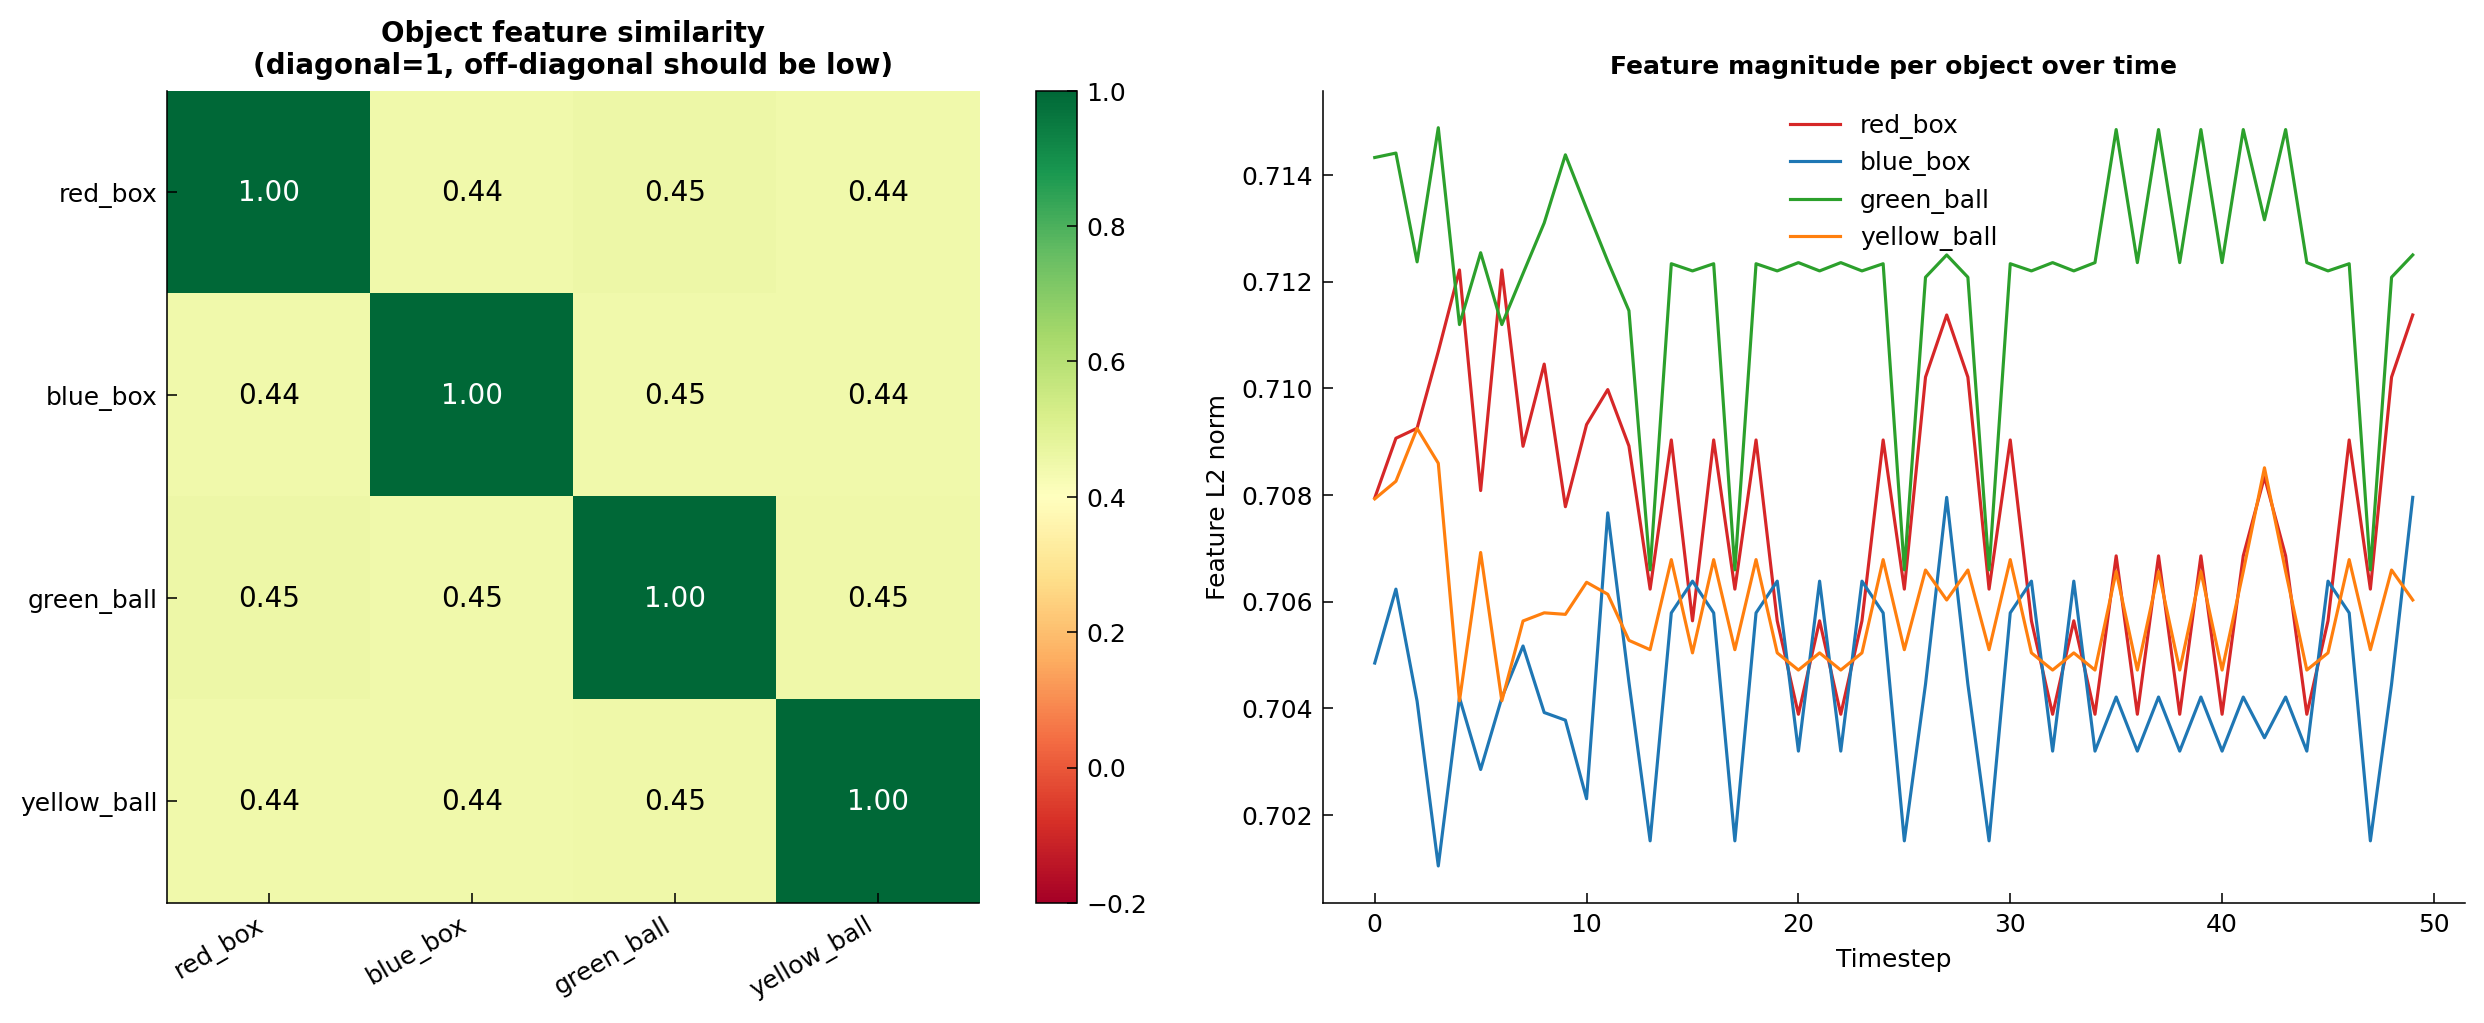

Max off-diagonal similarity: 0.453  (< 0.7 = clearly distinguishable)


In [25]:
# Pairwise cosine similarity of the pre-collected per-object feature vectors
mean_feats = feature_vectors.mean(axis=0)  # (n_objects, feat_dim)
norms = np.linalg.norm(mean_feats, axis=1, keepdims=True)
mean_feats_norm = mean_feats / np.maximum(norms, 1e-8)
sim_matrix = mean_feats_norm @ mean_feats_norm.T

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].imshow(sim_matrix, cmap='RdYlGn', vmin=-0.2, vmax=1.0)
axes[0].set_xticks(range(n_objects))
axes[0].set_xticklabels(landmark_labels, rotation=30, ha='right')
axes[0].set_yticks(range(n_objects))
axes[0].set_yticklabels(landmark_labels)
for i in range(n_objects):
    for j in range(n_objects):
        axes[0].text(j, i, f"{sim_matrix[i,j]:.2f}", ha='center', va='center',
                     fontsize=10, color='black' if abs(sim_matrix[i,j]) < 0.7 else 'white')
plt.colorbar(im, ax=axes[0])
axes[0].set_title("Object feature similarity\n(diagonal=1, off-diagonal should be low)", fontsize=10)

for i in range(n_objects):
    axes[1].plot(np.linalg.norm(feature_vectors[:, i, :], axis=1),
                 label=landmark_labels[i], color=COLORS[i])
axes[1].set_xlabel('Timestep'); axes[1].set_ylabel('Feature L2 norm')
axes[1].set_title('Feature magnitude per object over time')
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()
max_off = sim_matrix[~np.eye(n_objects, dtype=bool)].max()
print(f"Max off-diagonal similarity: {max_off:.3f}  (< 0.7 = clearly distinguishable)")

---
## Section 5 — Encode Features as Semantic Pointers

SSP space: domain=2D, ssp_dim=97


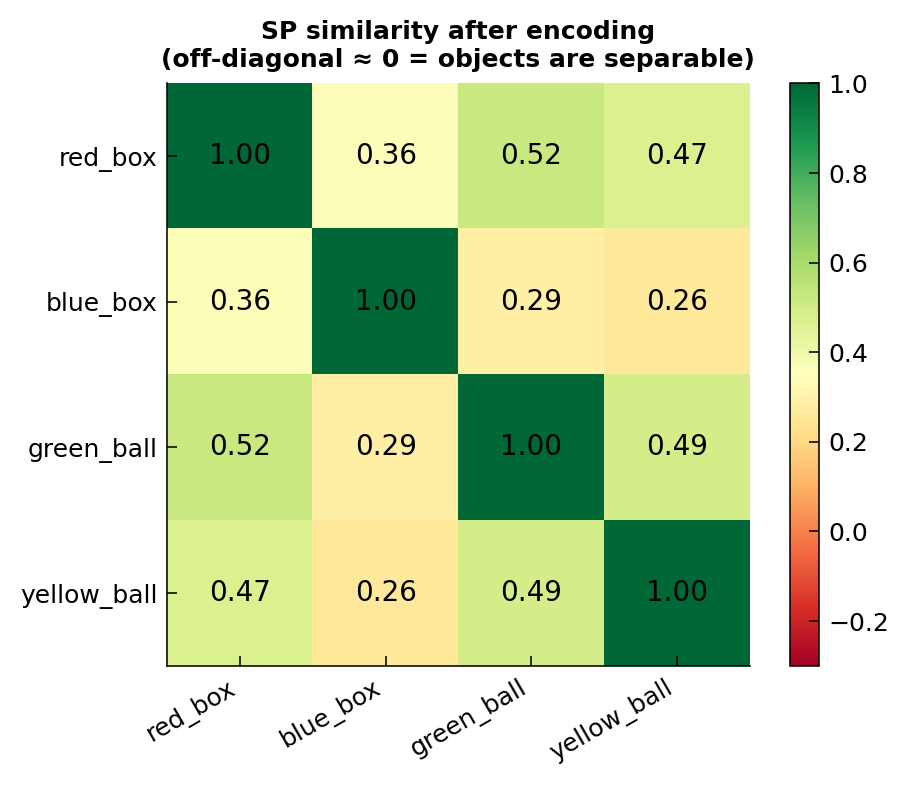

In [26]:
from sspslam import HexagonalSSPSpace
from sspslam.perception import ImageFeatureEncoder

SSP_DIM = 97
SEED    = 0

ssp_space = HexagonalSSPSpace(
    domain_dim=2, ssp_dim=SSP_DIM,
    domain_bounds=np.array([[-1, 1], [-1, 1]]),
    seed=SEED
)
ssp_dim = ssp_space.ssp_dim
print(f"SSP space: domain=2D, ssp_dim={ssp_dim}")

encoder = ImageFeatureEncoder(feat_dim=feat_dim, ssp_dim=ssp_dim, seed=SEED)

object_sps = np.vstack([
    encoder.encode(feature_vectors[:, j, :].mean(axis=0)[None]).squeeze()
    for j in range(n_objects)
])
sp_sim = object_sps @ object_sps.T

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sp_sim, cmap='RdYlGn', vmin=-0.3, vmax=1.0)
ax.set_xticks(range(n_objects)); ax.set_xticklabels(landmark_labels, rotation=30, ha='right')
ax.set_yticks(range(n_objects)); ax.set_yticklabels(landmark_labels)
for i in range(n_objects):
    for j in range(n_objects):
        ax.text(j, i, f"{sp_sim[i,j]:.2f}", ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax)
ax.set_title("SP similarity after encoding\n(off-diagonal ≈ 0 = objects are separable)")
plt.tight_layout(); plt.show()

---
## Section 6 — SSP Position Encoding
Nearby positions produce similar vectors; the space is periodic like grid cells.

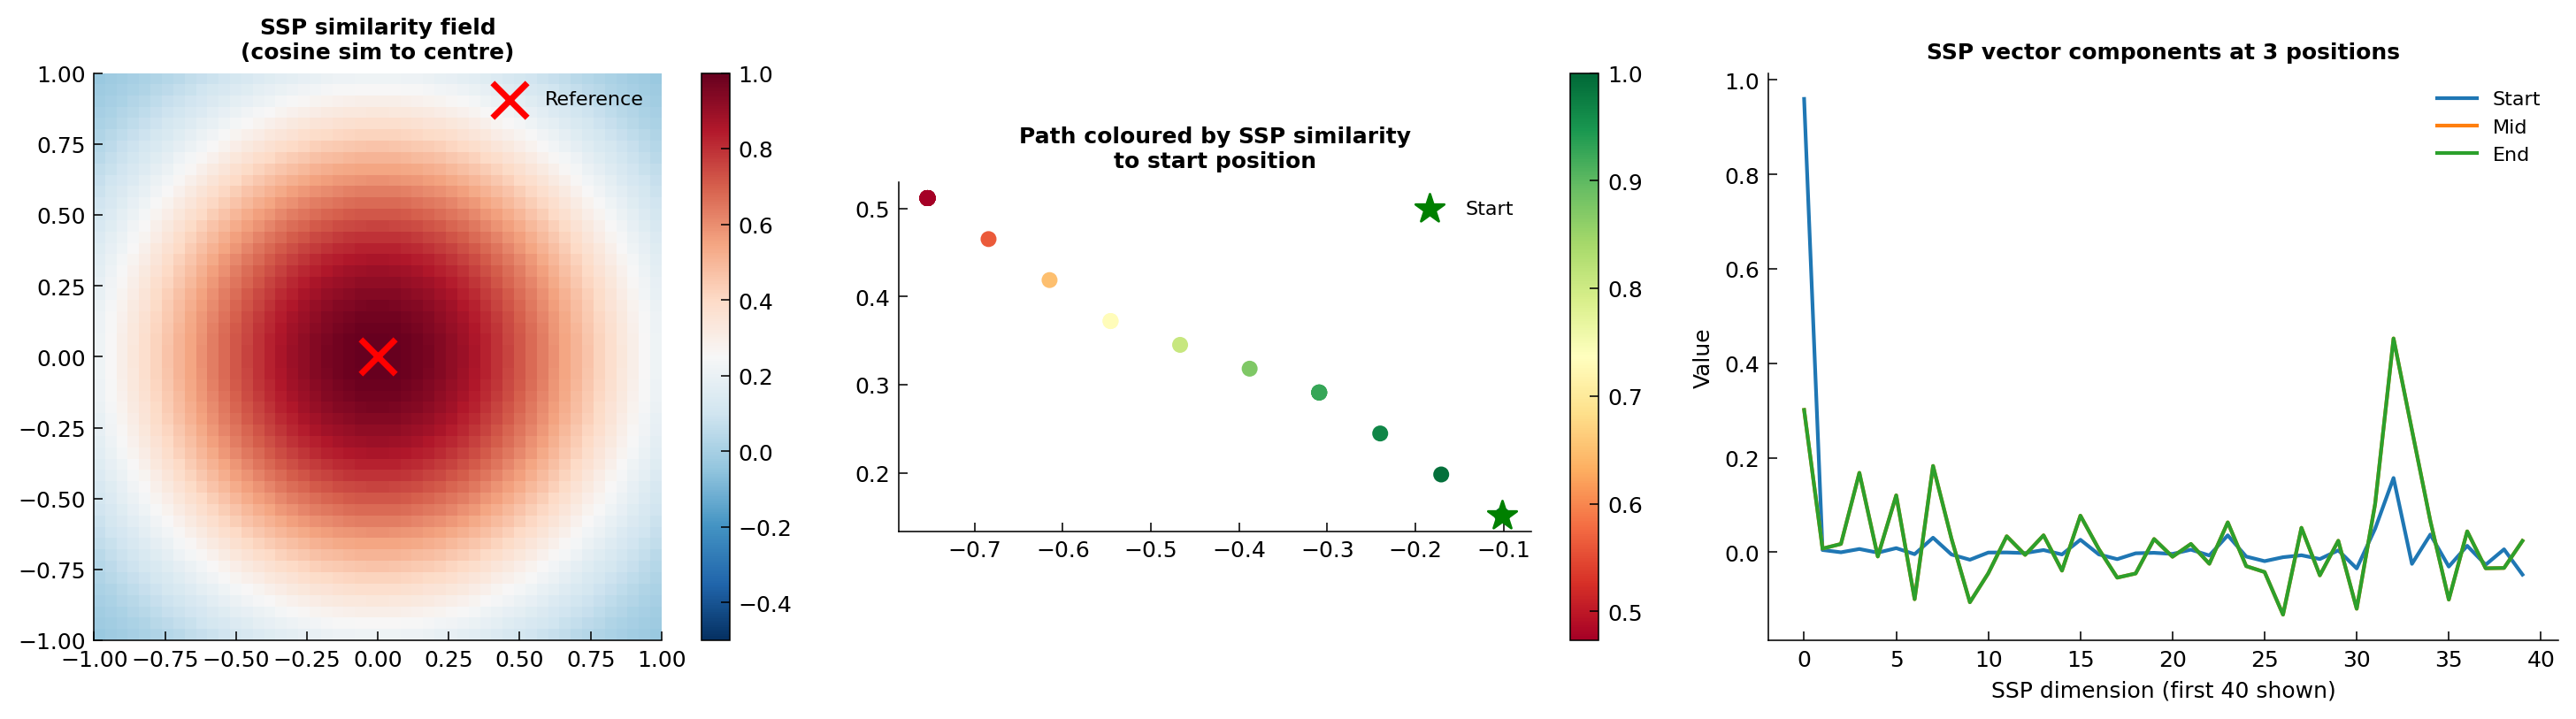

In [27]:
path_ssps  = ssp_space.encode(path)
start_ssp  = path_ssps[0]
sims_start = path_ssps @ start_ssp

res = 50
xs = np.linspace(-1, 1, res); ys = np.linspace(-1, 1, res)
xx, yy = np.meshgrid(xs, ys)
grid_pts_50  = np.stack([xx.ravel(), yy.ravel()], axis=1)
grid_ssps_50 = ssp_space.encode(grid_pts_50)
centre_ssp   = ssp_space.encode(np.array([[0., 0.]])).squeeze()
sims_grid    = (grid_ssps_50 @ centre_ssp).reshape(res, res)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im = axes[0].imshow(sims_grid, origin='lower', extent=[-1,1,-1,1],
                    cmap='RdBu_r', vmin=-0.5, vmax=1.0)
axes[0].scatter(0, 0, s=200, c='red', zorder=5, marker='x', linewidths=2.5, label='Reference')
plt.colorbar(im, ax=axes[0])
axes[0].set_title("SSP similarity field\n(cosine sim to centre)")
axes[0].legend(fontsize=8)

sc = axes[1].scatter(path[:,0], path[:,1], c=sims_start, cmap='RdYlGn', s=30)
axes[1].scatter(*path[0], s=150, c='green', marker='*', zorder=5, label='Start')
plt.colorbar(sc, ax=axes[1])
axes[1].set_aspect('equal')
axes[1].set_title("Path coloured by SSP similarity\nto start position")
axes[1].legend(fontsize=8)

for t_idx, lbl in [(0,'Start'), (len(path)//2,'Mid'), (-1,'End')]:
    axes[2].plot(path_ssps[t_idx, :40], label=lbl, lw=1.5)
axes[2].set_xlabel('SSP dimension (first 40 shown)')
axes[2].set_ylabel('Value')
axes[2].set_title('SSP vector components at 3 positions')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

---
## Section 7a — Load Pre-Saved SLAM Results *(recommended — fast)*
Loads the T=30 run saved in `data/3d/`.  
Skip to **Section 7b** if you want to run the SLAM from scratch (~2-3 min).

In [28]:
npz_files = sorted(glob.glob(os.path.join(DATA_DIR, "slam_features_*.npz")))

def _get_T(p):
    m = re.search(r'_T_(\d+)_', os.path.basename(p))
    return int(m.group(1)) if m else 0

if not npz_files:
    print("No saved SLAM results — run Section 7b first.")
    landmark_ssps_est = None
else:
    best = max(npz_files, key=_get_T)
    T_val = _get_T(best)
    print(f"Loading: {os.path.basename(best)}  (T={T_val}s)")

    saved = np.load(best, allow_pickle=True)
    print("Keys:", list(saved.keys()))

    landmark_ssps_est = saved["landmark_ssps_est"]   # (n_objects, ssp_dim_saved)
    landmark_loc_est  = saved["landmark_loc_est"]    # (n_objects, 2)
    slam_path         = saved["slam_path"]            # (T, 2)
    path_sim          = saved["path"]                 # (T, 2)
    obj_locs_saved    = saved["obj_locs"]             # (n_objects, 2)

    ssp_dim_saved = landmark_ssps_est.shape[1]
    if ssp_dim_saved != ssp_dim:
        print(f"Rebuilding SSP space: dim {ssp_dim} -> {ssp_dim_saved}")
        ssp_space = HexagonalSSPSpace(
            domain_dim=2, ssp_dim=ssp_dim_saved,
            domain_bounds=np.array([[-1,1],[-1,1]]), seed=SEED
        )
        ssp_dim = ssp_dim_saved

    err = np.linalg.norm(slam_path - path_sim[:len(slam_path)], axis=1)
    print(f"\nObjects: {landmark_ssps_est.shape[0]}  |  SSP dim: {ssp_dim}  |  Mean error: {err.mean():.4f}")
    for lbl, tp, ep in zip(landmark_labels, obj_locs_saved, landmark_loc_est):
        print(f"  {lbl:15s}  true={tp.round(3)}  est={ep.round(3)}  err={np.linalg.norm(tp-ep):.3f}")

Loading: slam_features_sspdim_97_featdim_128_pinneurons_300_T_30_seed_0.npz  (T=30s)
Keys: ['timesteps', 'ts', 'path', 'real_ssp', 'obj_locs', 'view_rad', 'slam_sim_out', 'slam_sims', 'slam_path', 'slam_error', 'landmark_ssps_est', 'landmark_loc_est', 'elapsed_time']

Objects: 4  |  SSP dim: 97  |  Mean error: 0.1223
  red_box          true=[0.459 0.126]  est=[-0.899  0.374]  err=1.380
  blue_box         true=[ 0.018 -0.649]  est=[ 0.03  -0.616]  err=0.035
  green_ball       true=[-0.424  0.377]  est=[-0.414  0.414]  err=0.038
  yellow_ball      true=[-0.865 -0.397]  est=[-0.899  0.374]  err=0.772


---
## Section 7b — Run SLAM from Scratch *(optional, ~2–3 min)*
Only run this if Section 7a found no saved results, or you want a fresh run.

In [29]:
import nengo
import sspslam
from sspslam.networks import SLAMNetwork, get_slam_input_functions_from_features

dt    = 0.001
T_run = 10.0
n_sim = int(T_run / dt)

def stretch(arr, n_out):
    t0 = np.linspace(0, 1, arr.shape[0])
    t1 = np.linspace(0, 1, n_out)
    if arr.ndim == 2:
        return np.stack([np.interp(t1, t0, arr[:, d]) for d in range(arr.shape[1])], axis=1)
    out = np.zeros((n_out, arr.shape[1], arr.shape[2]))
    for i in range(arr.shape[1]):
        for j in range(arr.shape[2]):
            out[:, i, j] = np.interp(t1, t0, arr[:, i, j])
    return out

path_sim = stretch(path, n_sim)
vel_sim  = stretch(velocities, n_sim)
vec_sim  = stretch(vec_to_landmarks, n_sim)
feat_sim = stretch(feature_vectors, n_sim)
vel_sc   = vel_sim / (np.abs(vel_sim).max() + 1e-8)
view_rad = meta.get("view_radius_normalized", 0.5)

(velocity_func, vel_scaling_factor,
 is_landmark_in_view, _, landmark_sp_func, _,
 landmark_vecssp_func) = get_slam_input_functions_from_features(
    ssp_space, encoder, vel_sc, vec_sim, feat_sim, view_rad, dt=dt
)

lm_sps   = encoder.encode(feat_sim.mean(axis=0))
lm_space = sspslam.SPSpace(n_objects, ssp_dim, seed=SEED, vectors=lm_sps)
real_ssp = ssp_space.encode(path_sim)

model = nengo.Network(seed=SEED)
with model:
    vel_node  = nengo.Node(velocity_func)
    init_node = nengo.Node(lambda t: real_ssp[min(int(t/dt), n_sim-1)] if t < 0.05 else np.zeros(ssp_dim))
    vec_node  = nengo.Node(landmark_vecssp_func)
    id_node   = nengo.Node(landmark_sp_func)
    view_node = nengo.Node(is_landmark_in_view)
    slam = SLAMNetwork(
        ssp_space, lm_space, view_rad, n_objects,
        300, 500, 70,
        tau_pi=0.05, update_thres=0.2,
        vel_scaling_factor=vel_scaling_factor,
        shift_rate=0.1, voja_learning_rate=1e-4, pes_learning_rate=5e-3,
        intercept=0.1, clean_up_method='grid', voja=True, seed=SEED,
    )
    nengo.Connection(vel_node,  slam.velocity_input, synapse=None)
    nengo.Connection(init_node, slam.pathintegrator.input, synapse=None)
    nengo.Connection(vec_node,  slam.landmark_vec_ssp, synapse=None)
    nengo.Connection(id_node,   slam.landmark_id_input, synapse=None)
    nengo.Connection(view_node, slam.no_landmark_in_view, synapse=None)
    pi_probe  = nengo.Probe(slam.pathintegrator.output, synapse=0.05)
    mem_probe = nengo.Probe(slam.assomemory.conn_out, 'weights', sample_every=T_run)

print("Running SLAM simulation...")
t0 = time.time()
with nengo.Simulator(model, dt=dt, progress_bar=True) as sim:
    sim.run(T_run)
elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s")

slam_out = sim.data[pi_probe]
mem_wts  = sim.data[mem_probe][-1].T
slam_path = ssp_space.decode(slam_out, 'from-set', 'grid', 100)
acts = nengo.builder.ensemble.get_activities(sim.data[slam.assomemory.memory],
                                              slam.assomemory.memory, lm_space.vectors)
landmark_ssps_est = np.dot(acts, mem_wts)
landmark_loc_est  = ssp_space.decode(landmark_ssps_est, 'from-set', 'grid', 100)
obj_locs_saved    = landmark_positions

err = np.linalg.norm(slam_path - path_sim[:len(slam_path)], axis=1)
print(f"Mean error: {err.mean():.4f}")

Running SLAM simulation...


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

Done in 50.5s
Mean error: 0.5169


---
## Section 8 — Cognitive Map: Spatial Recall Heatmaps

In [30]:
resolution = 60
xs = np.linspace(-1, 1, resolution)
ys = np.linspace(-1, 1, resolution)
xx, yy = np.meshgrid(xs, ys)
grid_pts  = np.stack([xx.ravel(), yy.ravel()], axis=1)
grid_ssps = ssp_space.encode(grid_pts)   # (3600, ssp_dim)
print(f"Query grid: {grid_ssps.shape}")

Query grid: (3600, 97)


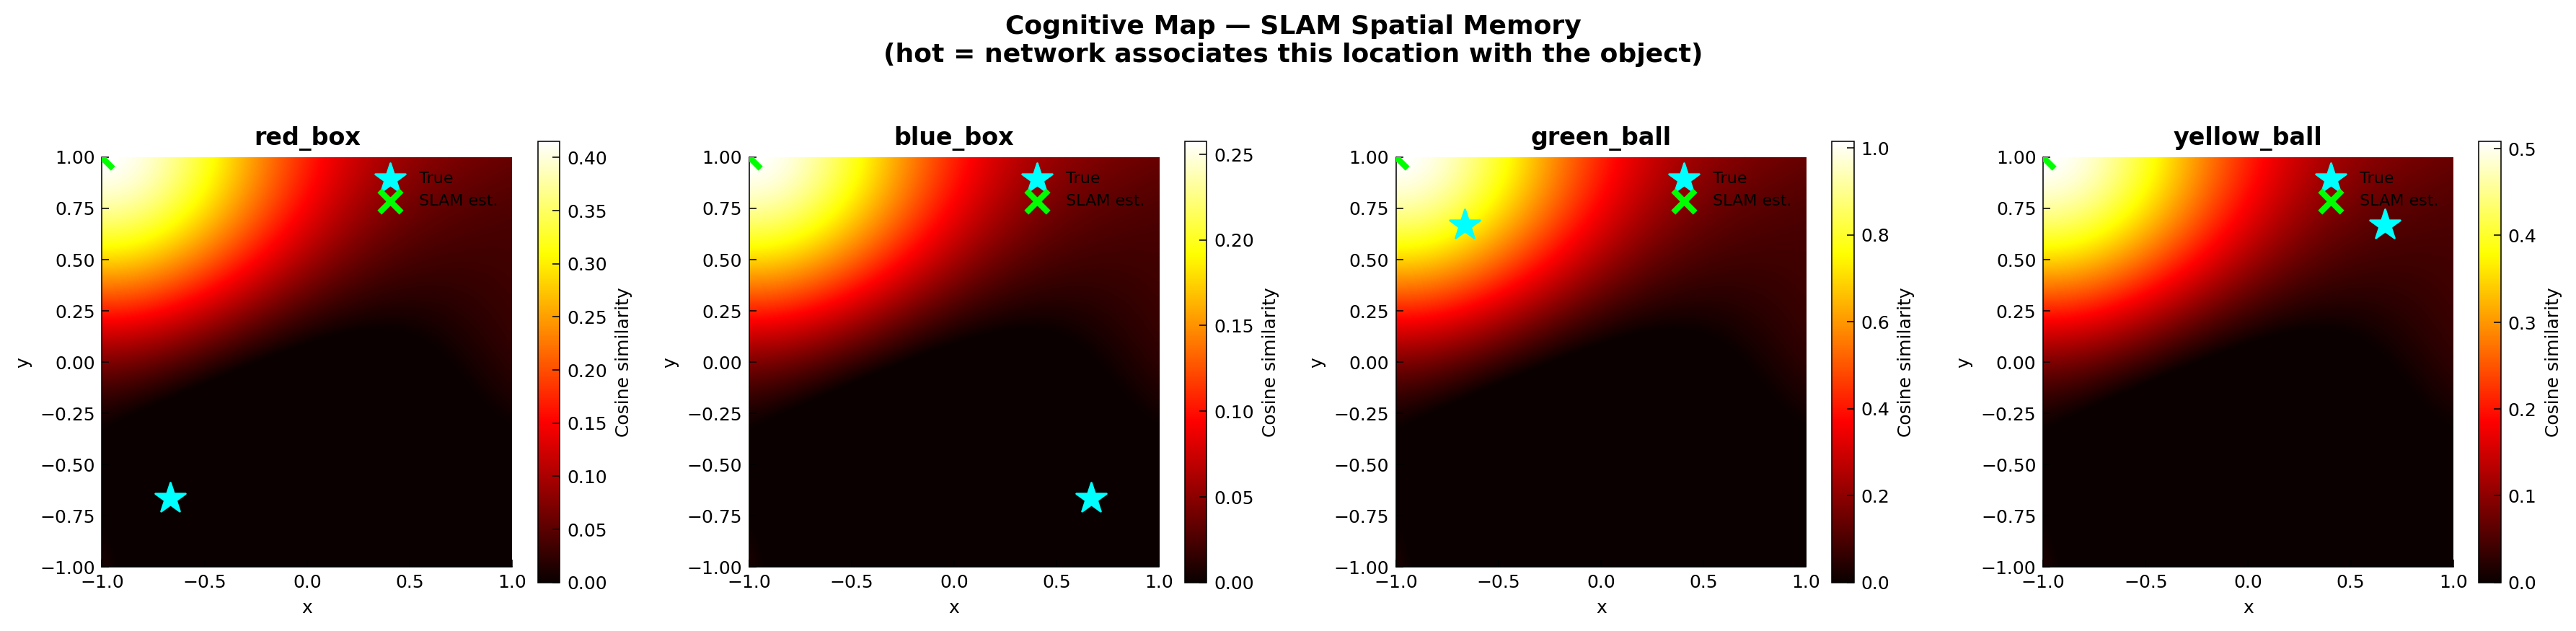

In [31]:
if landmark_ssps_est is None:
    print("No SLAM results — run Section 7a or 7b first.")
else:
    fig, axes = plt.subplots(1, n_objects, figsize=(4.5 * n_objects, 4.5))
    if n_objects == 1: axes = [axes]

    for i, ax in enumerate(axes):
        sims = (grid_ssps @ landmark_ssps_est[i]).reshape(resolution, resolution)
        im = ax.imshow(sims, origin='lower', extent=[-1,1,-1,1],
                       cmap='hot', interpolation='bilinear', vmin=0)
        ax.scatter(*obj_locs_saved[i], s=250, marker='*', color='cyan',
                   zorder=6, label='True')
        ax.scatter(*landmark_loc_est[i], s=120, marker='x', color='lime',
                   zorder=6, linewidths=3, label='SLAM est.')
        ax.set_title(landmark_labels[i], fontsize=12, fontweight='bold')
        ax.set_xlabel('x'); ax.set_ylabel('y')
        ax.legend(fontsize=8, loc='upper right')
        plt.colorbar(im, ax=ax, shrink=0.82, label='Cosine similarity')

    plt.suptitle("Cognitive Map — SLAM Spatial Memory\n"
                 "(hot = network associates this location with the object)",
                 fontsize=13)
    plt.tight_layout(); plt.show()

---
## Section 9 — Full Pipeline Summary

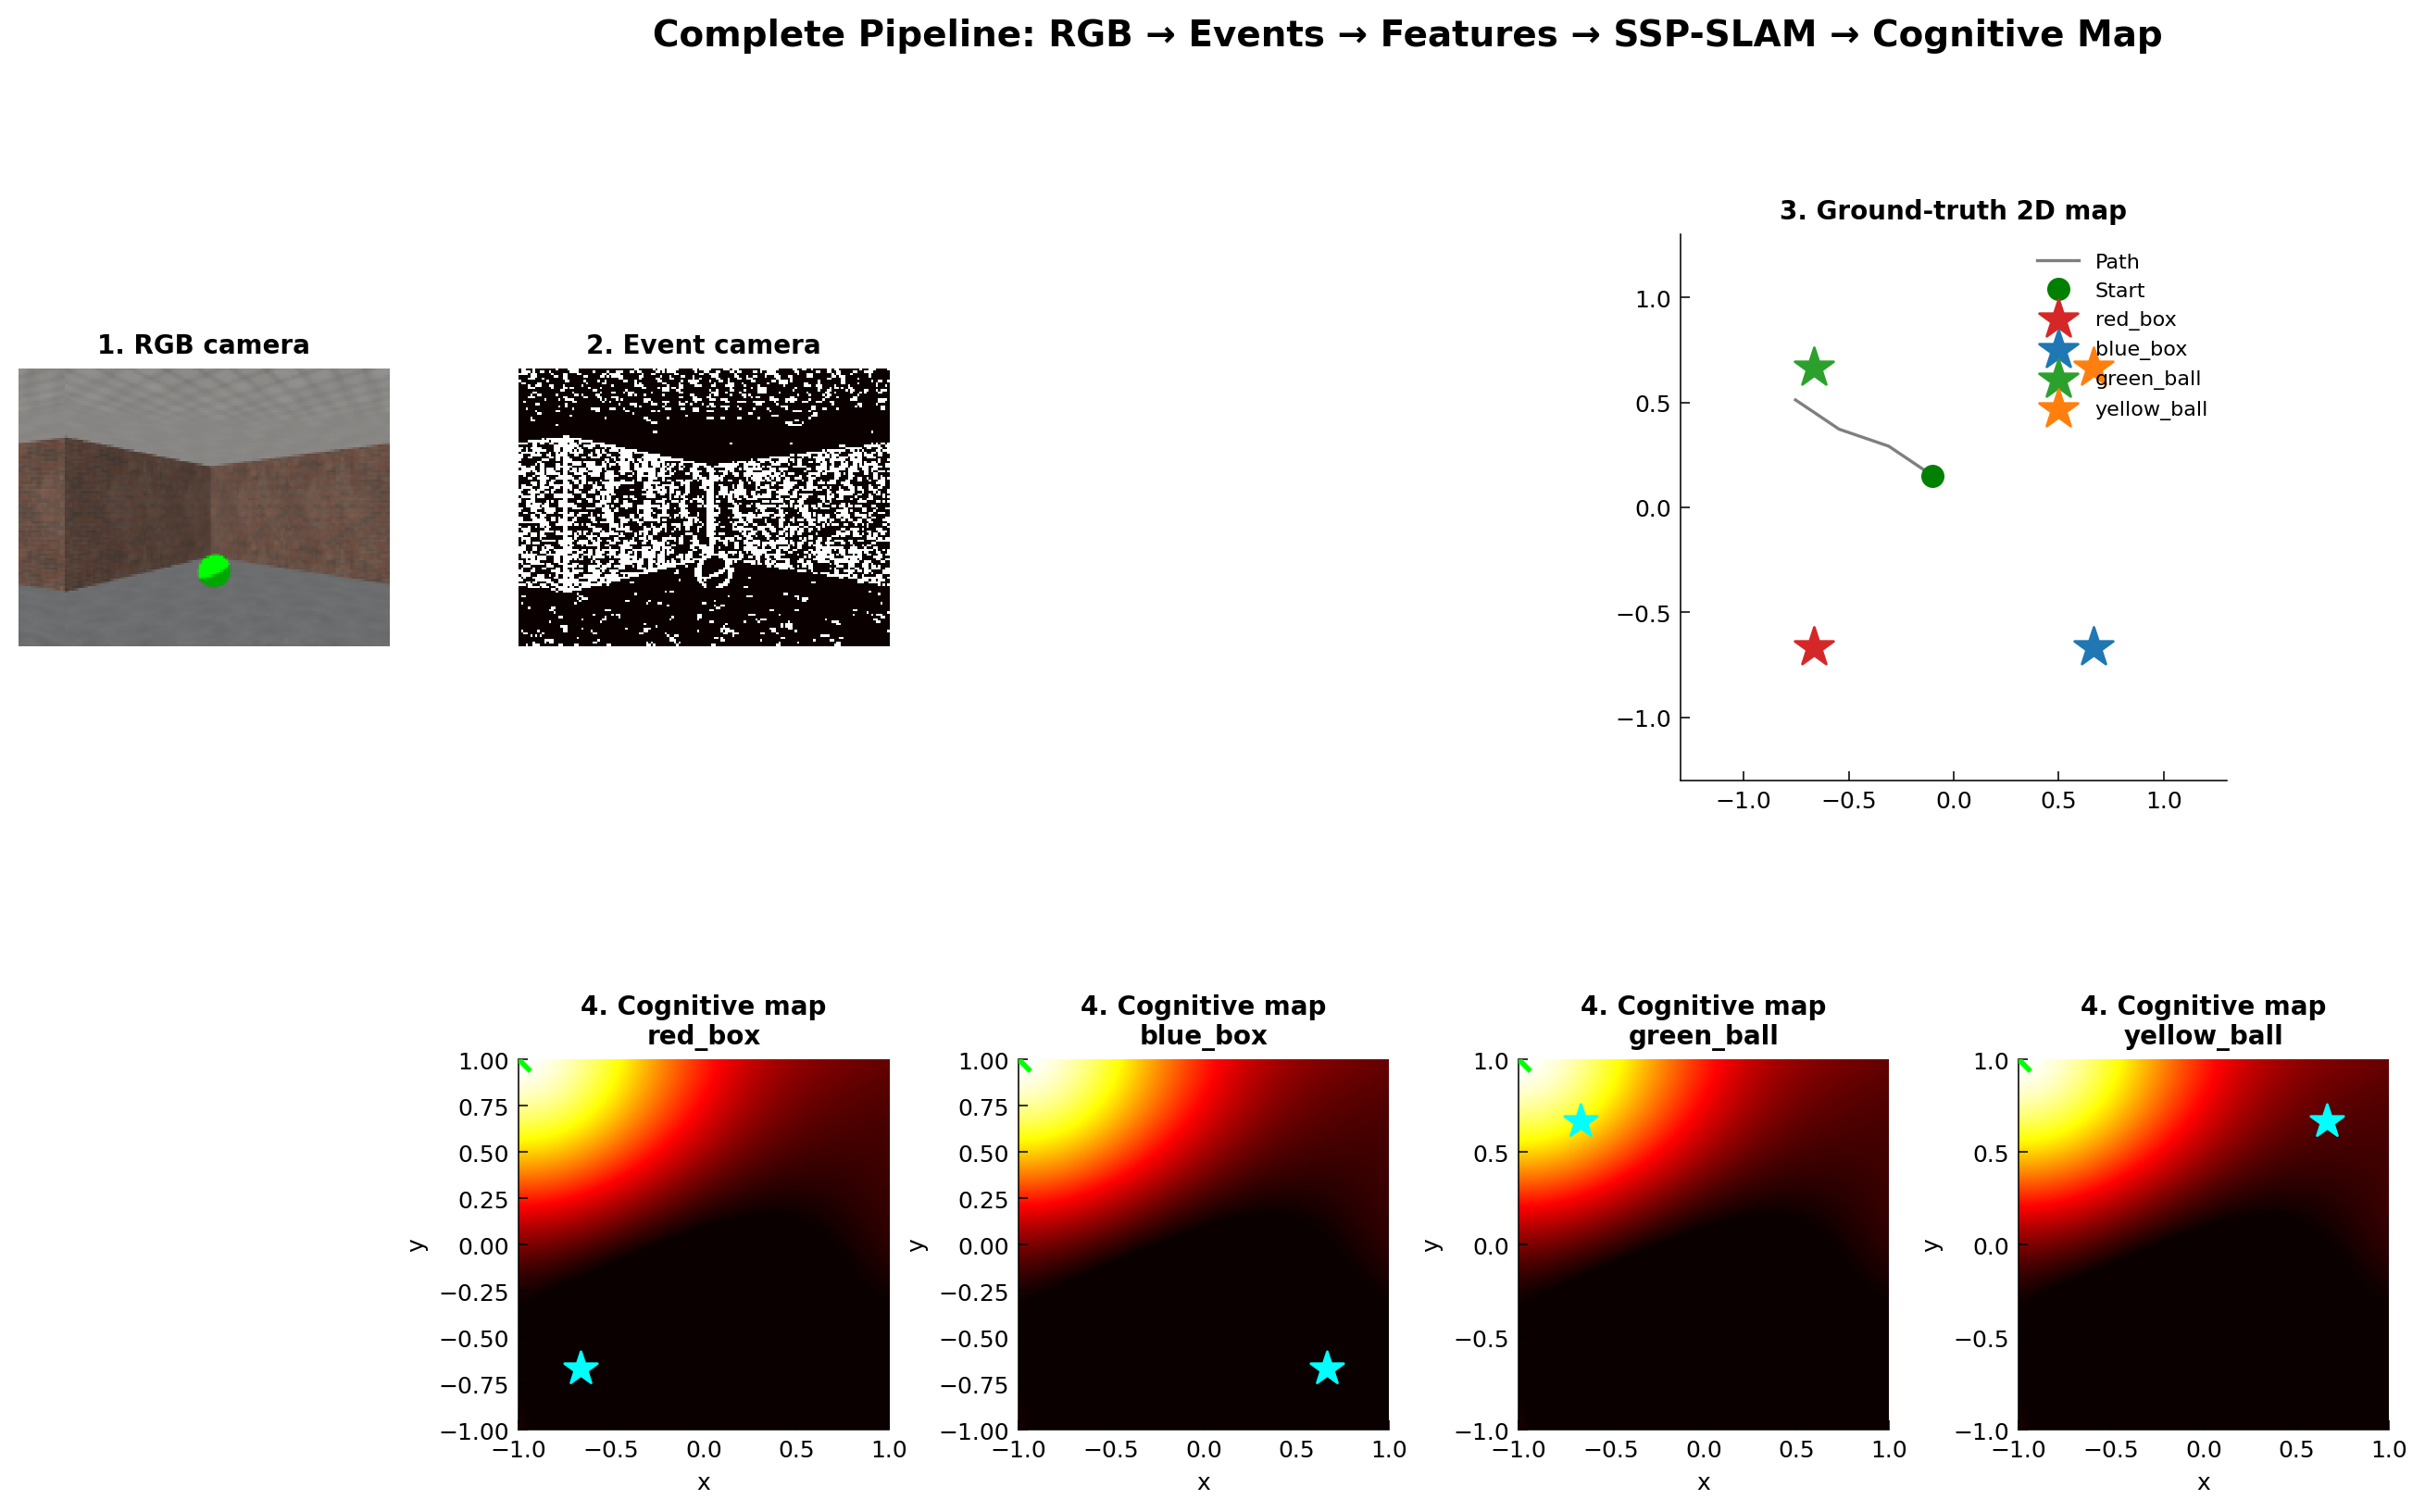

Saved to C:\Users\30068379\OneDrive - Western Sydney University\Code\Semantic-Spiking-Neural-SLAM-2023\data\3d\pipeline_summary.png


In [32]:
if landmark_ssps_est is None:
    print("Run Section 7a or 7b first to get SLAM results.")
else:
    fig = plt.figure(figsize=(20, 9))
    gs  = gridspec.GridSpec(2, n_objects + 2, figure=fig, hspace=0.35, wspace=0.35)

    # Row 0
    ax_rgb = fig.add_subplot(gs[0, 0])
    ax_rgb.imshow(rgb_frames[len(rgb_frames)//2])
    ax_rgb.axis('off')
    ax_rgb.set_title("1. RGB camera", fontsize=10)

    ax_ev = fig.add_subplot(gs[0, 1])
    mid_ev = len(event_frames) // 2
    ev_max = event_frames[mid_ev].max()
    ax_ev.imshow(event_frames[mid_ev], cmap='hot', vmin=0, vmax=max(ev_max, 1))
    ax_ev.axis('off')
    ax_ev.set_title("2. Event camera", fontsize=10)

    ax_map = fig.add_subplot(gs[0, 2:2+n_objects])
    ax_map.plot(path[:,0], path[:,1], 'k-', lw=1.2, alpha=0.5, label='Path')
    ax_map.plot(*path[0], 'go', ms=8, label='Start')
    for i, (pos, lbl) in enumerate(zip(landmark_positions, landmark_labels)):
        ax_map.scatter(*pos, s=250, marker='*', color=COLORS[i], zorder=5, label=lbl)
    ax_map.set_xlim(-1.3, 1.3); ax_map.set_ylim(-1.3, 1.3)
    ax_map.set_aspect('equal')
    ax_map.legend(fontsize=8, loc='upper right')
    ax_map.set_title("3. Ground-truth 2D map", fontsize=10)

    # Row 1 — cognitive map heatmaps
    for i in range(n_objects):
        ax = fig.add_subplot(gs[1, i + 1])
        sims = (grid_ssps @ landmark_ssps_est[i]).reshape(resolution, resolution)
        ax.imshow(sims, origin='lower', extent=[-1,1,-1,1],
                  cmap='hot', interpolation='bilinear', vmin=0)
        ax.scatter(*obj_locs_saved[i], s=180, marker='*', color='cyan', zorder=5)
        ax.scatter(*landmark_loc_est[i], s=80, marker='x', color='lime', zorder=5, linewidths=2)
        ax.set_title(f"4. Cognitive map\n{landmark_labels[i]}", fontsize=10)
        ax.set_xlabel('x'); ax.set_ylabel('y')

    plt.suptitle("Complete Pipeline: RGB → Events → Features → SSP-SLAM → Cognitive Map",
                 fontsize=14, fontweight='bold', y=1.01)
    out_png = os.path.join(DATA_DIR, "pipeline_summary.png")
    plt.savefig(out_png, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {out_png}")